In [ ]:
from typing import Dict, Any, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# ==========================================
# 1. 상태(State) 정의
# ==========================================
class AgentState(TypedDict):
    keywords: str                # 사용자가 입력한 구독 키워드
    raw_data: str                # 리서치 에이전트가 수집한 원시 데이터
    draft: str                   # 작성 에이전트가 생성한 뉴스레터 초안
    review_feedback: str         # 검수 에이전트의 수정 요청 피드백
    review_status: Literal["APPROVED", "REJECTED"]  # 검수 통과 여부
    revision_count: int          # 무한 루프 방지를 위한 수정 횟수 카운트

# %%
# ==========================================
# 2. 툴 함수 & 3. 노드(Node) 함수 정의
# ==========================================
def mock_search_tool(keywords: str) -> str:
    """웹 및 뉴스 API를 시뮬레이션하여 관련 원시 데이터를 반환하는 툴"""
    return f"[{keywords}] 관련 최신 트렌드 기사 핵심 내용 요약 데이터 (출처: Tavily/Google 뉴스 검색 API)"

def research_node(state: AgentState) -> Dict[str, Any]:
    print("\n[Node] 🔍 리서치 에이전트 가동")
    keywords = state.get("keywords", "")
    search_result = mock_search_tool(keywords)
    return {"raw_data": search_result, "revision_count": 0}

def writer_node(state: AgentState) -> Dict[str, Any]:
    print("\n[Node] ✍️ 작성 에이전트 가동")
    raw_data = state.get("raw_data", "")
    feedback = state.get("review_feedback", "")
    count = state.get("revision_count", 0)
    
    if feedback:
        print(f" -> [수정 요청 반영] 피드백({feedback})에 따라 내용을 보완합니다. (수정 횟수: {count})")
        draft = (
            f"📰 [뉴스레터 최종본] 구독자님을 위한 맞춤형 테크 브리핑\n\n"
            f"지난 초안의 어조를 보완하고 가독성을 개선한 버전입니다.\n"
            f"수집된 정보: {raw_data}\n\n"
            f"감사합니다."
        )
    else:
        print(" -> [초안 작성] 수집된 원시 데이터를 바탕으로 뉴스레터 템플릿을 적용합니다.")
        draft = (
            f"📰 [뉴스레터 초안] 구독자님을 위한 맞춤형 테크 브리핑\n\n"
            f"안녕하세요! 오늘 가져온 핵심 소식입니다.\n"
            f"콘텐츠 내용: {raw_data}\n\n"
            f"의견이 있으시면 피드백을 남겨주세요."
        )
        
    return {"draft": draft}

def review_node(state: AgentState) -> Dict[str, Any]:
    print("\n[Node] 🛠️ 검수 에이전트 가동")
    count = state.get("revision_count", 0)
    
    if count < 1:
        print(" -> [검수 결과] 품질 미달 판정: 전체적인 문체를 더 부드럽고 전문적으로 수정할 필요가 있습니다.")
        return {
            "review_status": "REJECTED",
            "review_feedback": "문체가 다소 딱딱합니다. 뉴스레터 톤앤매너에 맞게 친근하게 고쳐주세요.",
            "revision_count": count + 1
        }
    else:
        print(" -> [검수 결과] 품질 검증 통과 완료.")
        return {
            "review_status": "APPROVED",
            "review_feedback": "",
            "revision_count": count
        }

def send_newsletter_node(state: AgentState) -> Dict[str, Any]:
    print("\n[Node] 🚀 발송/저장 에이전트 가동")
    print("==================================================")
    print("최종 승인 완료! 사용자에게 이메일 발송 및 DB 저장을 수행합니다.")
    print(f"최종 발송 내용:\n{state.get('draft')}")
    print("==================================================")
    return {}

# %%
# ==========================================
# 4. 조건부 엣지 및 워크플로우 그래프 빌드
# ==========================================
def should_continue(state: AgentState) -> Literal["rewrite", "human_approval"]:
    status = state.get("review_status")
    count = state.get("revision_count", 0)
    
    if count >= 3:
        print("\n[System] 최대 수정 횟수 초과로 인해 강제로 승인 대기 단계로 진입합니다.")
        return "human_approval"
        
    if status == "REJECTED":
        return "rewrite"
    else:
        return "human_approval"

workflow = StateGraph(AgentState)

# 노드 등록
workflow.add_node("research_agent", research_node)
workflow.add_node("writer_agent", writer_node)
workflow.add_node("review_agent", review_node)
workflow.add_node("send_newsletter", send_newsletter_node)

# 엣지 연결
workflow.add_edge(START, "research_agent")
workflow.add_edge("research_agent", "writer_agent")
workflow.add_edge("writer_agent", "review_agent")

workflow.add_conditional_edges(
    "review_agent",
    should_continue,
    {
        "rewrite": "writer_agent",
        "human_approval": "send_newsletter"
    }
)

workflow.add_edge("send_newsletter", END)

# 체크포인터 등록 및 멈출 지점 지정
memory = MemorySaver()
app = workflow.compile(checkpointer=memory, interrupt_before=["send_newsletter"])


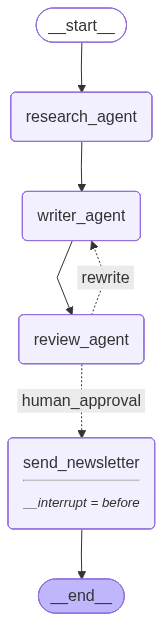

In [4]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            app.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

In [ ]:
# ==========================================
# 5. 실행 및 Human-in-the-loop 테스트
# ==========================================
if __name__ == "__main__":
    config = {"configurable": {"thread_id": "newsletter_task_001"}}
    initial_input = {"keywords": "2026년 AI 트렌드 및 에이전트 산업"}

    print("=== [1단계] 에이전트 자동화 프로세스 시작 ===")
    print("설명: 리서치 -> 작성 -> 검수(반려) -> 재작성 -> 검수(통과) 후 발송 직전에서 멈춥니다.")

    # 그래프 실행 시작
    for event in app.stream(initial_input, config=config, stream_mode="values"):
        print(event)
        print("---" * 15)
        
    print("\n=== [2단계] Human-in-the-loop 일시 중단 ===")
    current_state = app.get_state(config)

    print(f"현재 워크플로우 대기 위치 (Next Node): {current_state.next}")
    print(f"생성 완료된 초안 미리보기:\n{current_state.values.get('draft')}")
    # ----------------------------------------------------
    # 실행을 멈추고 사용자 입력을 대기하는 핵심 구간!
    # ----------------------------------------------------
    print("\n[시스템] 발송 대기 중입니다.")
    user_approval = input("최종 승인하시겠습니까? (y/n 입력 후 엔터): ")
    if user_approval.lower() == 'y':
        print("\n=== [3단계] 사용자가 '승인(y)'을 눌렀습니다. 실행을 재개합니다. ===")
        
        # None을 전달하여 멈췄던 곳(send_newsletter)부터 다시 실행
        for event in app.stream(None, config=config, stream_mode="values"):
            pass
        print("\n=== 프로세스 전체 종료 (발송 완료) ===")
    else:
        print("\n=== 사용자가 승인을 거절했습니다. 프로세스를 종료합니다. ===")

=== [1단계] 에이전트 자동화 프로세스 시작 ===
설명: 리서치 -> 작성 -> 검수(반려) -> 재작성 -> 검수(통과) 후 발송 직전에서 멈춥니다.
{'keywords': '2026년 AI 트렌드 및 에이전트 산업'}
---------------------------------------------

[Node] 🔍 리서치 에이전트 가동
{'keywords': '2026년 AI 트렌드 및 에이전트 산업', 'raw_data': '[2026년 AI 트렌드 및 에이전트 산업] 관련 최신 트렌드 기사 핵심 내용 요약 데이터 (출처: Tavily/Google 뉴스 검색 API)', 'revision_count': 0}
---------------------------------------------

[Node] ✍️ 작성 에이전트 가동
 -> [초안 작성] 수집된 원시 데이터를 바탕으로 뉴스레터 템플릿을 적용합니다.
{'keywords': '2026년 AI 트렌드 및 에이전트 산업', 'raw_data': '[2026년 AI 트렌드 및 에이전트 산업] 관련 최신 트렌드 기사 핵심 내용 요약 데이터 (출처: Tavily/Google 뉴스 검색 API)', 'draft': '📰 [뉴스레터 초안] 구독자님을 위한 맞춤형 테크 브리핑\n\n안녕하세요! 오늘 가져온 핵심 소식입니다.\n콘텐츠 내용: [2026년 AI 트렌드 및 에이전트 산업] 관련 최신 트렌드 기사 핵심 내용 요약 데이터 (출처: Tavily/Google 뉴스 검색 API)\n\n의견이 있으시면 피드백을 남겨주세요.', 'revision_count': 0}
---------------------------------------------

[Node] 🛠️ 검수 에이전트 가동
 -> [검수 결과] 품질 미달 판정: 전체적인 문체를 더 부드럽고 전문적으로 수정할 필요가 있습니다.
{'keywords': '2026년 AI 트렌드 및 에이전트 산업', 'raw_data': '[2026년 AI 트렌드 및 


=== [3단계] 사용자가 '승인(y)'을 눌렀습니다. 실행을 재개합니다. ===

[Node] 🚀 발송/저장 에이전트 가동
최종 승인 완료! 사용자에게 이메일 발송 및 DB 저장을 수행합니다.
최종 발송 내용:
📰 [뉴스레터 최종본] 구독자님을 위한 맞춤형 테크 브리핑

지난 초안의 어조를 보완하고 가독성을 개선한 버전입니다.
수집된 정보: [2026년 AI 트렌드 및 에이전트 산업] 관련 최신 트렌드 기사 핵심 내용 요약 데이터 (출처: Tavily/Google 뉴스 검색 API)

감사합니다.

=== 프로세스 전체 종료 (발송 완료) ===
